## Coding Exercise #0703b

### 1. PCA with linear AutoEncoder:

In [8]:
import tensorflow as tf
from tensorflow import keras

In [9]:
# Import the common module.
import numpy as np
import os

# To maintain the execution result
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
# To display a graph
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [11]:
# To draw a black-and-white image
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

In [12]:
# 3D dataset
np.random.seed(4)

def generate_3d_data(m, w1=0.1, w2=0.3, noise=0.1):
    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
    data[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
    data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * np.random.randn(m)
    return data

X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0, keepdims=0)

In [13]:
# AutoEncoder
np.random.seed(42)
tf.random.set_seed(42)

encoder = keras.models.Sequential([keras.layers.Dense(2, input_shape=[3])])
decoder = keras.models.Sequential([keras.layers.Dense(3, input_shape=[2])])
autoencoder = keras.models.Sequential([encoder, decoder])

autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1.5))
history = autoencoder.fit(X_train, X_train, epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2964 
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1285
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2135
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1875
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0331
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0202
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0193
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0219
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0252
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0259
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0226
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0177
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0138
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0113
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0098
Epoch 16/20
2/2 ━━━━━━━━━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


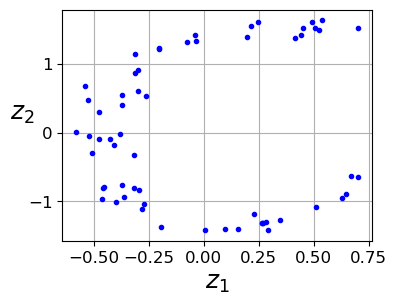

In [14]:
codings = encoder.predict(X_train)
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)

plt.show()